# Seminar: Analyzing Uniswap from Every Angle

In this seminar we take **Uniswap** as a single protocol and look at it through every level of the blockchain data pyramid:

1. **Raw onchain** (web3py) — direct RPC reads of the USDC/WETH V3 pool
2. **Etherscan API** — UNI token transactions and contract activity
3. **Indexers (The Graph)** — historical pool OHLCV and volume
4. **Aggregators (DeFiLlama)** — TVL across versions and chains
5. **Specialized (GeckoTerminal)** — top pools on Uniswap V3
6. **Market data (CoinGecko, Binance)** — UNI token price, volume, market cap
7. **Cross-source analysis** — compare what each tool gave us

The onchain and Etherscan sections are intentionally minimal (single snapshot reads, no multi-block scans) because free indexed APIs give the same information faster and cheaper.

## 0. Setup

In [1]:
# Core imports
import os
import json
import time
from datetime import datetime, timedelta

import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Plot style
plt.style.use('ggplot')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (12, 5)})
pd.set_option('display.max_columns', 30)

In [5]:
# API keys — set these in your environment or paste directly.
# Most cells will work with placeholders; sections that strictly need a key will say so.
ETH_HTTP_NODE    = os.environ.get('ETH_HTTP_NODE',   '')  # public fallback
ETHERSCAN_API_KEY = os.environ.get('ETHERSCAN_API_KEY', '')
THEGRAPH_API_KEY  = os.environ.get('THEGRAPH_API_KEY',  '')
DUNE_API_KEY = os.environ.get('DUNE_API_KEY', '')

# Uniswap addresses (Ethereum mainnet)
UNI_V3_USDC_WETH_POOL = '0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640'  # 0.05% fee tier
UNI_TOKEN            = '0x1f9840a85d5aF5bf1D1762F925BDADdC4201F984'
WETH                 = '0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2'
USDC                 = '0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48'

## 1. Raw onchain data (web3py)

One snapshot RPC read: current pool state, tokens, decimals, current price from `slot0`.
We do **not** scan swap event history here — that's what indexers are for.

In [ ]:
!pip3 install web3

In [7]:
from web3 import Web3

w3 = Web3(Web3.HTTPProvider(ETH_HTTP_NODE))
print(f"Connected: {w3.is_connected()}, latest block: {w3.eth.block_number}")

Connected: True, latest block: 24950789


In [8]:
# Minimal ABI — only the read functions we need
POOL_ABI_MIN = [
    {"inputs":[],"name":"slot0","outputs":[
        {"name":"sqrtPriceX96","type":"uint160"},{"name":"tick","type":"int24"},
        {"name":"observationIndex","type":"uint16"},{"name":"observationCardinality","type":"uint16"},
        {"name":"observationCardinalityNext","type":"uint16"},{"name":"feeProtocol","type":"uint8"},
        {"name":"unlocked","type":"bool"}],"stateMutability":"view","type":"function"},
    {"inputs":[],"name":"token0","outputs":[{"type":"address"}],"stateMutability":"view","type":"function"},
    {"inputs":[],"name":"token1","outputs":[{"type":"address"}],"stateMutability":"view","type":"function"},
    {"inputs":[],"name":"fee","outputs":[{"type":"uint24"}],"stateMutability":"view","type":"function"},
    {"inputs":[],"name":"liquidity","outputs":[{"type":"uint128"}],"stateMutability":"view","type":"function"},
]
ERC20_ABI_MIN = [
    {"inputs":[],"name":"symbol","outputs":[{"type":"string"}],"stateMutability":"view","type":"function"},
    {"inputs":[],"name":"decimals","outputs":[{"type":"uint8"}],"stateMutability":"view","type":"function"},
]

pool = w3.eth.contract(address=Web3.to_checksum_address(UNI_V3_USDC_WETH_POOL), abi=POOL_ABI_MIN)

# Pool state — a single round-trip of cheap read calls
token0_addr = pool.functions.token0().call()
token1_addr = pool.functions.token1().call()
fee         = pool.functions.fee().call()
liquidity   = pool.functions.liquidity().call()
slot0       = pool.functions.slot0().call()

t0 = w3.eth.contract(address=token0_addr, abi=ERC20_ABI_MIN)
t1 = w3.eth.contract(address=token1_addr, abi=ERC20_ABI_MIN)
sym0, dec0 = t0.functions.symbol().call(), t0.functions.decimals().call()
sym1, dec1 = t1.functions.symbol().call(), t1.functions.decimals().call()

print(f"Pool: {sym0}/{sym1}, fee: {fee/10000}%")
print(f"Liquidity (raw): {liquidity}")
print(f"Current tick: {slot0[1]}, sqrtPriceX96: {slot0[0]}")

Pool: USDC/WETH, fee: 0.05%
Liquidity (raw): 3366955734162263624
Current tick: 198838, sqrtPriceX96: 1645812880331388859473985338904071


In [9]:
# Price from sqrtPriceX96: price(token1/token0) = (sqrtPriceX96 / 2^96)^2, adjusted for decimals
sqrt_price_x96 = slot0[0]
price_t1_per_t0 = (sqrt_price_x96 / (2**96))**2 * (10**(dec0 - dec1))

# USDC/WETH pool: token0 = USDC, token1 = WETH, so price_t1_per_t0 = WETH per USDC
eth_price_usd = 1 / price_t1_per_t0
print(f"1 WETH = {eth_price_usd:,.2f} USDC   (from Uniswap V3 slot0)")

1 WETH = 2,317.39 USDC   (from Uniswap V3 slot0)


## 2. Etherscan API

Cheap, fast source for account-level data. We use it for the **UNI governance token** — recent transactions and basic info. No block-range scans.

In [10]:
# Etherscan API V2 (V1 was deprecated Aug 15 2025). Single endpoint, chainid param.
BASE = 'https://api.etherscan.io/v2/api'

def etherscan(**params):
    params['chainid'] = 1            # Ethereum mainnet
    params['apikey'] = ETHERSCAN_API_KEY
    r = requests.get(BASE, params=params, timeout=15)
    return r.json()

# Recent UNI token transfers (last 100 events for the token contract)
resp = etherscan(module='account', action='tokentx',
                 contractaddress=UNI_TOKEN, page=1, offset=10_000, sort='desc')
uni_tx = pd.DataFrame(resp.get('result', []))
if len(uni_tx):
    uni_tx['timeStamp'] = pd.to_datetime(uni_tx['timeStamp'].astype(int), unit='s')
    uni_tx['value_uni'] = uni_tx['value'].astype(float) / 10**18
uni_tx[['timeStamp', 'from', 'to', 'value_uni', 'hash']].head()

,timeStamp,from,to,value_uni,hash
0,2026-04-24 15:49:23,0xb9e9e795fd530314663f779f7f57950c6bc1eb4b,0x000000000004444c5dc75cb358380d2e3de08a90,7.467844,0x835b6367613602cb4a313bcfd9c26456f66a5976604c...
1,2026-04-24 15:49:23,0xd0fc8ba7e267f2bc56044a7715a489d851dc6d78,0xb9e9e795fd530314663f779f7f57950c6bc1eb4b,7.467844,0x835b6367613602cb4a313bcfd9c26456f66a5976604c...
2,2026-04-24 15:49:23,0x8488ff4c8b54900f6576347e4a0fcd282449dbe5,0x91d40e4818f4d4c57b4578d9eca6afc92ac8debe,130.661566,0x0d7cd8cfadb36e4ec58df92802c3f9b2d15f3ea3c231...
3,2026-04-24 15:48:35,0x974caa59e49682cda0ad2bbe82983419a2ecc400,0xae6074b7b3ab4006295bc63c7f4d92d2dabf3c3a,0.307028,0xa304d996856aa763792ae93007d6c7a001806836a5e4...
4,2026-04-24 15:45:47,0x5386512190c0c83c608dc0e8ce1fbe7644de07e2,0xe8e1f50392bd61d0f8f48e8e7af51d3b8a52090a,2070.172119,0x7f1671eb2ea30f43ded7073ed492bfe06acc3ef43dea...


In [13]:
uni_tx.describe()

,timeStamp,value_uni
count,10000,1.000000e+04
mean,2026-04-22 21:51:57,2.467727e+03
min,2026-04-21 03:29:59,0.000000e+00
25%,2026-04-22 02:41:29,1.233934e+01
50%,2026-04-22 23:58:35,2.231998e+02
75%,2026-04-23 17:02:17,6.136808e+02
max,2026-04-24 15:49:23,1.792730e+06
std,NaN,3.327612e+04


In [17]:
uni_tx = uni_tx[(uni_tx.value_uni > 1.233934e+01) & (uni_tx.value_uni < 6.136808e+02)]

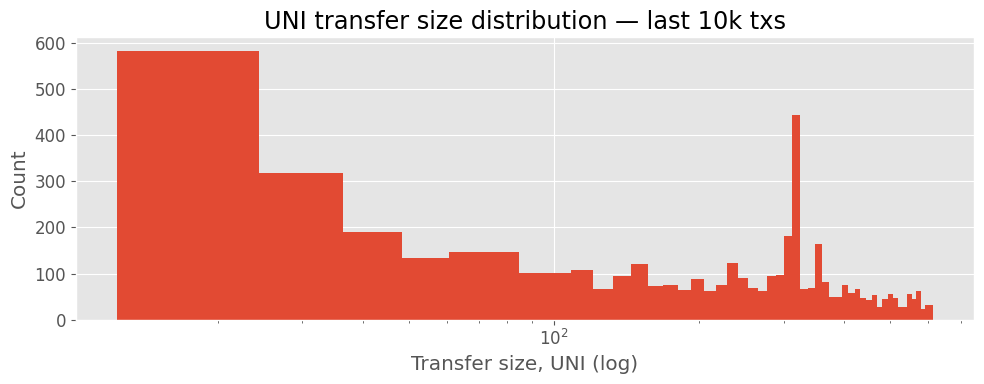

In [18]:
# Distribution of transfer sizes (log scale)
if len(uni_tx):
    fig, ax = plt.subplots(figsize=(10, 4))
    uni_tx['value_uni'].replace(0, np.nan).dropna().hist(bins=50, ax=ax)
    ax.set_xscale('log')
    ax.set_xlabel('Transfer size, UNI (log)')
    ax.set_ylabel('Count')
    ax.set_title('UNI transfer size distribution — last 10k txs')
    plt.tight_layout(); plt.show()

## 3. The Graph — historical pool data

Uniswap V3 subgraph: hourly aggregates (OHLCV + volume) for the most active pool.

In [46]:
SUBGRAPH_ID = '5zvR82QoaXYFyDEKLZ9t6v9adgnptxYpKpSbxtgVENFV'  # Uniswap V3
GRAPH_URL = f'https://gateway.thegraph.com/api/{THEGRAPH_API_KEY}/subgraphs/id/{SUBGRAPH_ID}'

query = '''
{
  pools(orderBy: volumeUSD, orderDirection: desc, first: 1) {
    id
    token0 { symbol }
    token1 { symbol }
    poolHourData(first: 500, orderBy: periodStartUnix, orderDirection: desc) {
      periodStartUnix volumeUSD token0Price token1Price
      open high low close tvlUSD
    }
  }
}
'''
resp = requests.post(GRAPH_URL, json={'query': query}, timeout=30).json()
pool = resp['data']['pools'][0]
print(f"Top pool: {pool['token0']['symbol']}/{pool['token1']['symbol']} @ {pool['id']}")

hr = pd.json_normalize(pool['poolHourData'])
hr['datetime'] = pd.to_datetime(hr['periodStartUnix'], unit='s')
num_cols = ['volumeUSD', 'token0Price', 'token1Price', 'open', 'high', 'low', 'close', 'tvlUSD']
hr[num_cols] = hr[num_cols].astype(float)
hr = hr.sort_values('datetime').reset_index(drop=True)
hr.tail()

Top pool: USDC/WETH @ 0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640


,close,high,low,open,periodStartUnix,token0Price,token1Price,tvlUSD,volumeUSD,datetime
495,2324.953690,2334.969079,2320.930921,2329.574422,1777032000,2324.953690,0.000430,3.990369e+08,1.920298e+06,2026-04-24 12:00:00
496,2317.479396,2331.546176,2313.231585,2326.139247,1777035600,2317.479396,0.000432,3.984488e+08,2.012791e+06,2026-04-24 13:00:00
497,2314.628926,2318.828448,2305.818369,2317.483505,1777039200,2314.628926,0.000432,3.979775e+08,2.486959e+06,2026-04-24 14:00:00
498,2323.799343,2329.687556,2304.427095,2314.641326,1777042800,2323.799343,0.000430,3.988685e+08,2.507038e+06,2026-04-24 15:00:00
499,2315.395900,2324.413592,2312.426102,2323.817330,1777046400,2315.395900,0.000432,3.985100e+08,1.510985e+06,2026-04-24 16:00:00


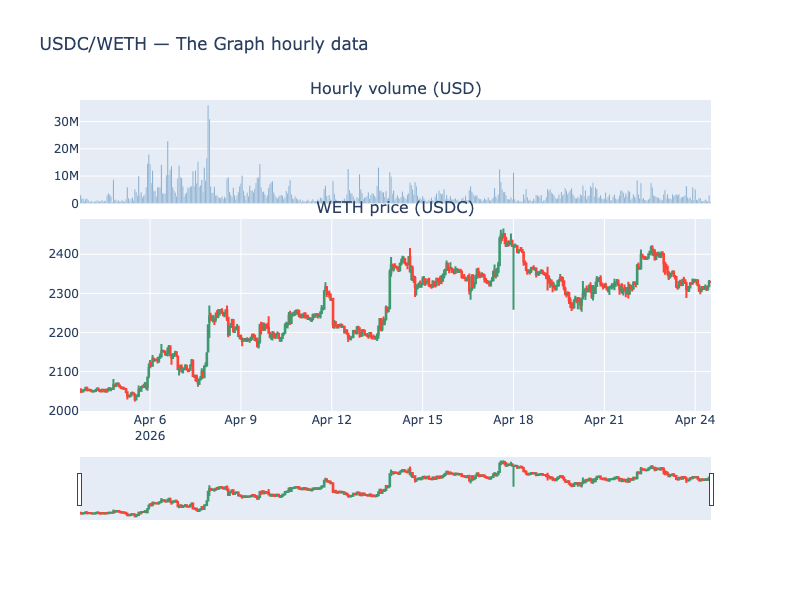

In [9]:
# Volume + price on one figure
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=('Hourly volume (USD)', 'WETH price (USDC)'),
                    row_heights=[0.35, 0.65])
fig.add_trace(go.Bar(x=hr['datetime'], y=hr['volumeUSD'], name='Volume', marker_color='#4682B4'), 1, 1)
fig.add_trace(go.Candlestick(x=hr['datetime'], open=hr['open'], high=hr['high'],
                             low=hr['low'], close=hr['close'], name='Price'), 2, 1)
fig.update_layout(height=600, showlegend=False, xaxis_rangeslider_visible=False,
                  title=f"{pool['token0']['symbol']}/{pool['token1']['symbol']} — The Graph hourly data")
fig.show()

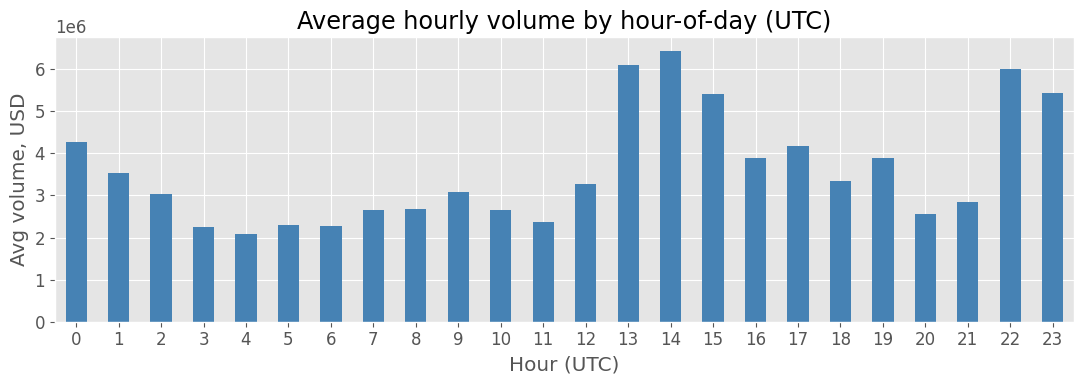

In [10]:
# Hour-of-day volume pattern — when do people trade the most
hr['hour_utc'] = hr['datetime'].dt.hour
hourly_vol = hr.groupby('hour_utc')['volumeUSD'].mean()

plt.figure(figsize=(11, 4))
hourly_vol.plot(kind='bar', color='#4682B4')
plt.title('Average hourly volume by hour-of-day (UTC)')
plt.xlabel('Hour (UTC)'); plt.ylabel('Avg volume, USD')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

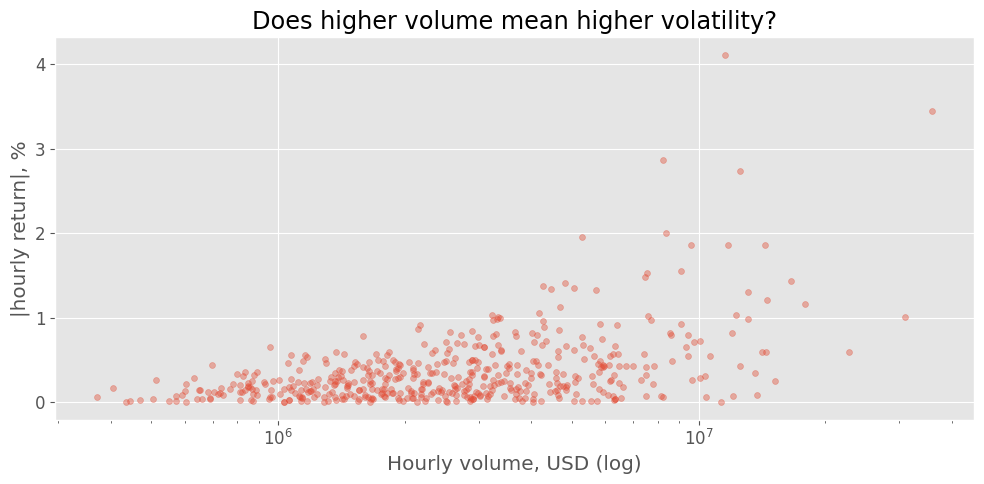

Pearson correlation: 0.531


In [11]:
# Volatility (returns) vs volume — are high-volume hours more volatile?
hr['ret'] = hr['close'].pct_change()
hr['abs_ret'] = hr['ret'].abs()

plt.figure(figsize=(10, 5))
plt.scatter(hr['volumeUSD'], hr['abs_ret']*100, alpha=0.4, s=18)
plt.xscale('log')
plt.xlabel('Hourly volume, USD (log)')
plt.ylabel('|hourly return|, %')
plt.title('Does higher volume mean higher volatility?')
plt.tight_layout(); plt.show()

corr = hr[['volumeUSD', 'abs_ret']].corr().iloc[0, 1]
print(f"Pearson correlation: {corr:.3f}")

## 4. Dune Analytics — two ways via SDK

Two canonical patterns with `dune-client`:

1. **Raw SQL** — `dune.create_query(...)` then `dune.run_query_dataframe(...)`. Creates a private query on your account and executes it. Costs credits.
2. **By query_id** — `dune.get_latest_result(QUERY_ID)`. Returns the cached result of any existing query (yours or anyone's on Dune). Does **not** spend credits — good for reusing community dashboards.

In [ ]:
!pip3 install dune_client

In [20]:
from dune_client.client import DuneClient
from dune_client.query import QueryBase

dune = DuneClient(DUNE_API_KEY)

In [ ]:
# Example 1 — Raw SQL via SDK.
# We compare Uniswap's weekly volume against other DEXes on Ethereum (180d).
SQL = """
SELECT
  date_trunc('week', block_time) AS week,
  project,
  SUM(amount_usd)                AS volume_usd
FROM dex.trades
WHERE blockchain = 'ethereum'
  AND block_time > NOW() - INTERVAL '180' day
  AND project IN ('uniswap', 'curve', 'balancer', 'sushiswap', 'pancakeswap', 'dodo', 'maverick')
GROUP BY 1, 2
ORDER BY 1
"""

# Creates a private query on your Dune account, then executes it
query_obj = dune.create_query(
    name="ethereum DEX weekly volume (180d)",
    query_sql=SQL,
    is_private=True,
)
print(f"Query created: query_id={query_obj.base.query_id}, url={query_obj.base.url()}")

dex_df = dune.run_query_dataframe(QueryBase(query_id=query_obj.base.query_id))
dex_df['week'] = pd.to_datetime(dex_df['week'])
dex_df['volume_usd'] = dex_df['volume_usd'].astype(float)
dex_df = dex_df.sort_values('week').reset_index(drop=True)
print(f"Rows: {len(dex_df)}, projects: {sorted(dex_df['project'].unique())}")
dex_df.head()

In [23]:
QUERY_ID = 7369747

result = dune.get_latest_result(QUERY_ID)
result_df = pd.DataFrame(result.result.rows)
print(f"Rows: {len(result_df)}, columns: {list(result_df.columns)}")
result_df.head(20)

Rows: 189, columns: ['project', 'volume_usd', 'week']


,project,volume_usd,week
0,maverick,5.316821e+06,2025-10-20 00:00:00.000 UTC
1,sushiswap,4.308779e+06,2025-10-20 00:00:00.000 UTC
2,dodo,1.068931e+07,2025-10-20 00:00:00.000 UTC
3,pancakeswap,2.559770e+06,2025-10-20 00:00:00.000 UTC
4,balancer,6.050963e+06,2025-10-20 00:00:00.000 UTC
5,uniswap,1.286386e+09,2025-10-20 00:00:00.000 UTC
6,curve,7.434028e+07,2025-10-20 00:00:00.000 UTC
7,uniswap,2.358595e+10,2025-10-27 00:00:00.000 UTC
8,pancakeswap,6.620915e+07,2025-10-27 00:00:00.000 UTC
9,balancer,1.997430e+08,2025-10-27 00:00:00.000 UTC


<Axes: >

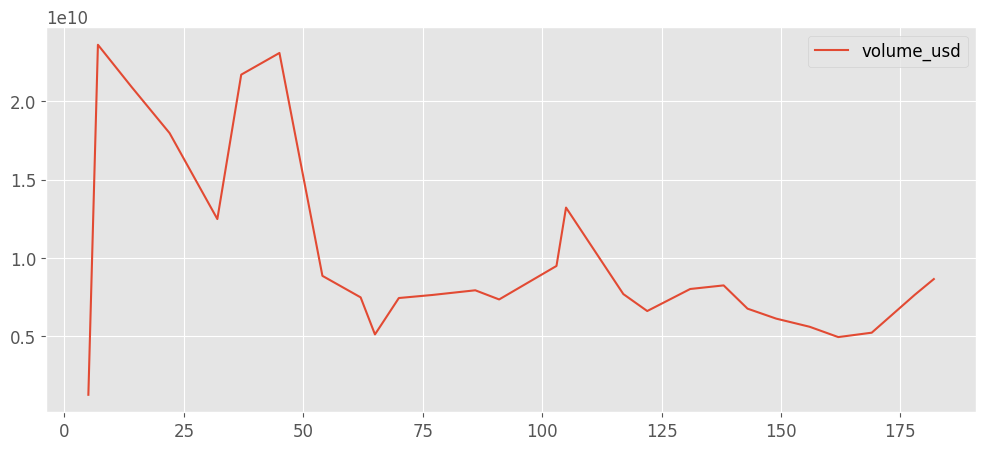

In [25]:
result_df[result_df.project == 'uniswap'].plot()

In [22]:
# Example 2 — Existing query by ID. Put any public query_id from dune.com here.
# 4319 -- same data but custom
QUERY_ID = 4319

result = dune.get_latest_result(QUERY_ID)
result_df = pd.DataFrame(result.result.rows)
print(f"Rows: {len(result_df)}, columns: {list(result_df.columns)}")
result_df.head(20)

Rows: 158, columns: ['24 Hours Volume', '7 Days Volume', 'Project', 'Rank']


,24 Hours Volume,7 Days Volume,Project,Rank
0,2.139341e+09,3.672295e+10,pancakeswap,1
1,2.278667e+09,2.038888e+10,uniswap,2
2,2.444539e+08,4.190776e+09,curve,3
3,4.780795e+08,3.909300e+09,aerodrome,4
4,2.681387e+08,3.490199e+09,fluid,5
5,6.731791e+07,6.898246e+08,native,6
6,3.188446e+07,5.319392e+08,openocean,7
7,7.223818e+07,4.328483e+08,quickswap,8
8,3.625940e+07,4.182272e+08,dodo,9
9,6.287399e+07,4.128716e+08,trader_joe,10


## 5. DeFiLlama — TVL across versions and chains

No API key required. We compare Uniswap V1 / V2 / V3 / V4 side-by-side and look at where V3 TVL lives by chain.

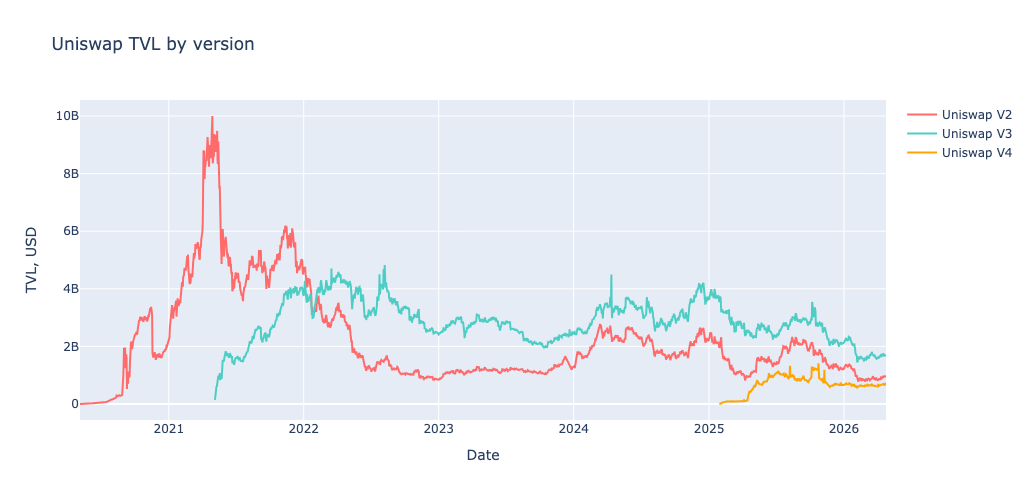

In [19]:
def llama_tvl(slug):
    data = requests.get(f'https://api.llama.fi/protocol/{slug}', timeout=20).json()
    df = pd.DataFrame(data['tvl'])
    df['date'] = pd.to_datetime(df['date'], unit='s')
    return df, data

tvl_v2, data_v2 = llama_tvl('uniswap-v2')
tvl_v3, data_v3 = llama_tvl('uniswap-v3')
tvl_v4, data_v4 = llama_tvl('uniswap-v4')

fig = go.Figure()
for name, df, color in [('V2', tvl_v2, '#ff6b6b'), ('V3', tvl_v3, '#4ecdc4'), ('V4', tvl_v4, '#ffa502')]:
    fig.add_trace(go.Scatter(x=df['date'], y=df['totalLiquidityUSD'],
                             name=f'Uniswap {name}', mode='lines', line=dict(color=color)))
fig.update_layout(title='Uniswap TVL by version', xaxis_title='Date',
                  yaxis_title='TVL, USD', height=500, hovermode='x unified')
fig.show()

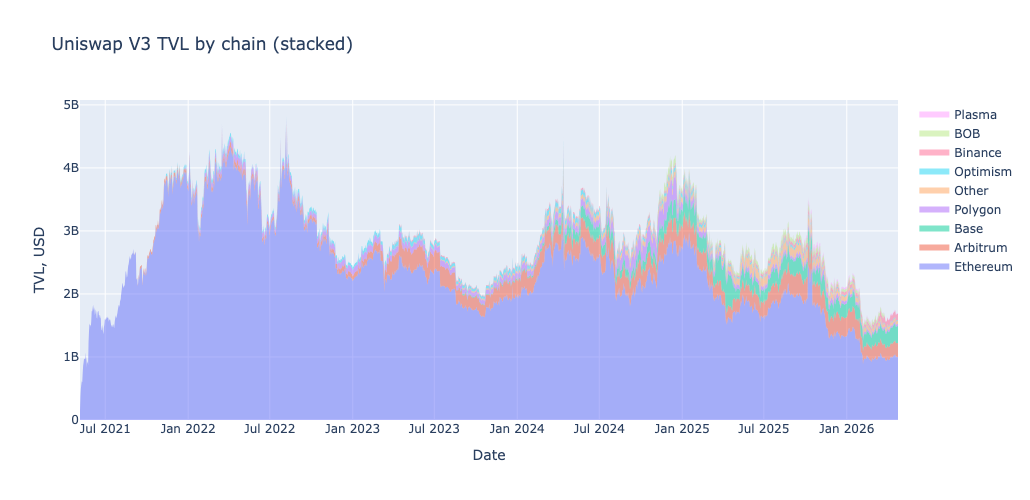

In [26]:
# V3 multichain split — stacked area
rows = []
for chain, chain_data in data_v3['chainTvls'].items():
    if 'tvl' not in chain_data: continue
    for p in chain_data['tvl']:
        rows.append({'date': p['date'], 'chain': chain, 'tvl': p['totalLiquidityUSD']})
chains_df = pd.DataFrame(rows)
chains_df['date'] = pd.to_datetime(chains_df['date'], unit='s')

# Keep top 8 chains by peak TVL, bucket the rest as Other
peak = chains_df.groupby('chain')['tvl'].max().sort_values(ascending=False)
top = peak.head(8).index.tolist()
chains_df['chain'] = chains_df['chain'].where(chains_df['chain'].isin(top), 'Other')

pivot = chains_df.groupby(['date', 'chain'])['tvl'].sum().unstack(fill_value=0)
pivot = pivot[pivot.sum().sort_values(ascending=False).index]  # sort columns by total size

fig = go.Figure()
for c in pivot.columns:
    fig.add_trace(go.Scatter(x=pivot.index, y=pivot[c], name=c, stackgroup='one', mode='none'))
fig.update_layout(title='Uniswap V3 TVL by chain (stacked)',
                  xaxis_title='Date', yaxis_title='TVL, USD', height=500)
fig.show()

In [27]:
# Uniswap TVL dominance = (Uniswap V2+V3+V4) / total DeFi TVL
total_resp = requests.get('https://api.llama.fi/v2/historicalChainTvl', timeout=20).json()
total_df = pd.DataFrame(total_resp)
total_df['date'] = pd.to_datetime(total_df['date'], unit='s')
total_df = total_df.rename(columns={'tvl': 'total_defi_tvl'})[['date', 'total_defi_tvl']]

# Combine Uniswap versions by date
parts = []
for name, df in [('v2', tvl_v2), ('v3', tvl_v3), ('v4', tvl_v4)]:
    parts.append(df[['date', 'totalLiquidityUSD']].rename(columns={'totalLiquidityUSD': name}))

uni_combined = parts[0]
for p in parts[1:]:
    uni_combined = uni_combined.merge(p, on='date', how='outer')
uni_combined = uni_combined.fillna(0).sort_values('date').reset_index(drop=True)
uni_combined['uniswap_total'] = uni_combined[['v2', 'v3', 'v4']].sum(axis=1)

# Merge with total DeFi TVL
uni_combined['date'] = uni_combined['date'].astype('datetime64[ns]')
total_df['date']     = total_df['date'].astype('datetime64[ns]')
dom = pd.merge_asof(uni_combined.sort_values('date'),
                    total_df.sort_values('date'),
                    on='date', direction='nearest')
dom = dom[dom['total_defi_tvl'] > 0].copy()
dom['dominance_pct'] = dom['uniswap_total'] / dom['total_defi_tvl'] * 100

print(f"Latest Uniswap TVL:     ${dom['uniswap_total'].iloc[-1]/1e9:,.2f}B")
print(f"Latest total DeFi TVL:  ${dom['total_defi_tvl'].iloc[-1]/1e9:,.2f}B")
print(f"Latest dominance:       {dom['dominance_pct'].iloc[-1]:.2f}%")
print(f"All-time max dominance: {dom['dominance_pct'].max():.2f}%  on  {dom.loc[dom['dominance_pct'].idxmax(),'date'].date()}")

Latest Uniswap TVL:     $1.69B
Latest total DeFi TVL:  $83.62B
Latest dominance:       2.03%
All-time max dominance: 30.55%  on  2020-10-28


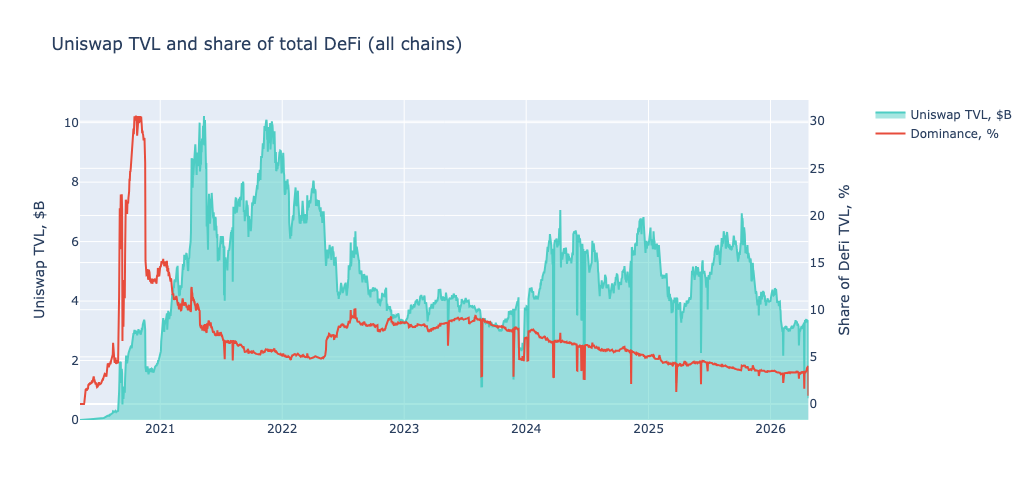

In [28]:
# Uniswap TVL (area) + dominance (line, secondary axis)
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Scatter(x=dom['date'], y=dom['uniswap_total']/1e9,
                         name='Uniswap TVL, $B', fill='tozeroy',
                         line=dict(color='#4ecdc4')), secondary_y=False)
fig.add_trace(go.Scatter(x=dom['date'], y=dom['dominance_pct'],
                         name='Dominance, %', line=dict(color='#e74c3c', width=2)),
              secondary_y=True)
fig.update_yaxes(title_text='Uniswap TVL, $B', secondary_y=False)
fig.update_yaxes(title_text='Share of DeFi TVL, %', secondary_y=True)
fig.update_layout(title='Uniswap TVL and share of total DeFi (all chains)',
                  height=500, hovermode='x unified')
fig.show()

## 6. GeckoTerminal — top pools on Uniswap V3

Specialized DEX analytics. Public API, no key needed.

In [ ]:
url = 'https://api.geckoterminal.com/api/v2/networks/eth/dexes/uniswap_v3/pools'
resp = requests.get(url, headers={'Accept': 'application/json'}, timeout=20).json()

pools = []
for p in resp['data']:
    a = p['attributes']
    pools.append({
        'pool': a['name'],
        'address': p['id'].replace('eth_', ''),
        'volume_24h': float(a['volume_usd']['h24'] or 0),
        'reserve_usd': float(a['reserve_in_usd'] or 0),
        'price_change_24h': float(a['price_change_percentage']['h24'] or 0),
        'tx_count_24h': a['transactions']['h24']['buys'] + a['transactions']['h24']['sells'],
    })
pools_df = pd.DataFrame(pools).sort_values('volume_24h', ascending=False).reset_index(drop=True)
pools_df.head(10)

In [ ]:
# Top 10 pools by 24h volume
top10 = pools_df.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top10['pool'], top10['volume_24h'] / 1e6, color='#4ecdc4')
ax.set_xlabel('24h volume, $M')
ax.set_title('Top 10 Uniswap V3 pools by 24h volume (Ethereum)')
plt.tight_layout(); plt.show()

In [ ]:
# Volume vs liquidity — capital efficiency snapshot
fig = px.scatter(pools_df.head(20), x='reserve_usd', y='volume_24h',
                 hover_name='pool', size='tx_count_24h',
                 log_x=True, log_y=True,
                 labels={'reserve_usd': 'Liquidity, USD', 'volume_24h': '24h Volume, USD'},
                 title='Top 20 pools: volume vs liquidity (marker size = tx count)')
fig.show()

## 7. Market data — CoinGecko and Binance

UNI governance token from two independent sources: a price aggregator (CoinGecko) and a CEX (Binance).

In [41]:
# CoinGecko: UNI last 90 days
cg = requests.get('https://api.coingecko.com/api/v3/coins/uniswap/market_chart',
                  params={'vs_currency': 'usd', 'days': 360}, timeout=20).json()

uni_cg = pd.DataFrame(cg['prices'], columns=['ts', 'price'])
uni_cg['datetime'] = pd.to_datetime(uni_cg['ts'], unit='ms')
uni_cg['volume'] = [v[1] for v in cg['total_volumes']]
uni_cg['mcap']   = [v[1] for v in cg['market_caps']]
uni_cg.tail()

,ts,price,datetime,volume,mcap
356,1776729600000,3.231651,2026-04-21 00:00:00,1.859185e+08,2.046759e+09
357,1776816000000,3.271942,2026-04-22 00:00:00,1.572412e+08,2.074634e+09
358,1776902400000,3.321316,2026-04-23 00:00:00,1.646367e+08,2.104770e+09
359,1776988800000,3.295830,2026-04-24 00:00:00,1.644823e+08,2.088189e+09
360,1777049081000,3.244235,2026-04-24 16:44:41,1.406340e+08,2.055790e+09


In [42]:
# Binance UNI/USDT daily klines
kl = requests.get('https://api.binance.com/api/v3/klines',
                  params={'symbol': 'UNIUSDT', 'interval': '1d', 'limit': 360}, timeout=20).json()
uni_bn = pd.DataFrame(kl, columns=['open_time','open','high','low','close','volume',
                                   'close_time','qav','trades','tbbav','tbqav','ignore'])
uni_bn['datetime'] = pd.to_datetime(uni_bn['open_time'], unit='ms')
for c in ['open','high','low','close','volume']:
    uni_bn[c] = uni_bn[c].astype(float)
uni_bn.tail()

,open_time,open,high,low,close,volume,close_time,qav,trades,tbbav,tbqav,ignore,datetime
355,1776643200000,3.232,3.336,3.197,3.233,2609008.94,1776729599999,8502760.02054000,51705,1310259.89000000,4270947.22664000,0,2026-04-20
356,1776729600000,3.233,3.297,3.185,3.271,2327147.18,1776815999999,7556490.08912000,53045,1270927.54000000,4128573.04231000,0,2026-04-21
357,1776816000000,3.273,3.439,3.258,3.315,3273370.62,1776902399999,11045568.04952000,51655,1831668.25000000,6181716.99352000,0,2026-04-22
358,1776902400000,3.317,3.329,3.208,3.294,3438069.63,1776988799999,11227049.04926000,55975,1751943.49000000,5722669.43585000,0,2026-04-23
359,1776988800000,3.294,3.313,3.222,3.241,1971365.30,1777075199999,6428496.56184000,32514,974850.98000000,3180515.50235000,0,2026-04-24


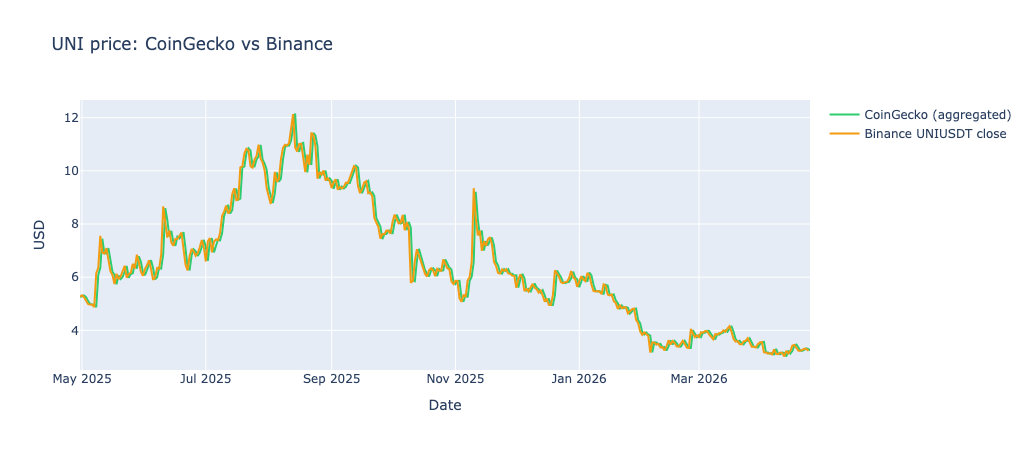

In [43]:
# CoinGecko (aggregated) vs Binance (single CEX) — UNI price side by side
fig = go.Figure()
fig.add_trace(go.Scatter(x=uni_cg['datetime'], y=uni_cg['price'],
                         name='CoinGecko (aggregated)', line=dict(color='#2ecc71')))
fig.add_trace(go.Scatter(x=uni_bn['datetime'], y=uni_bn['close'],
                         name='Binance UNIUSDT close', line=dict(color='#f39c12')))
fig.update_layout(title='UNI price: CoinGecko vs Binance',
                  xaxis_title='Date', yaxis_title='USD', height=450, hovermode='x unified')
fig.show()

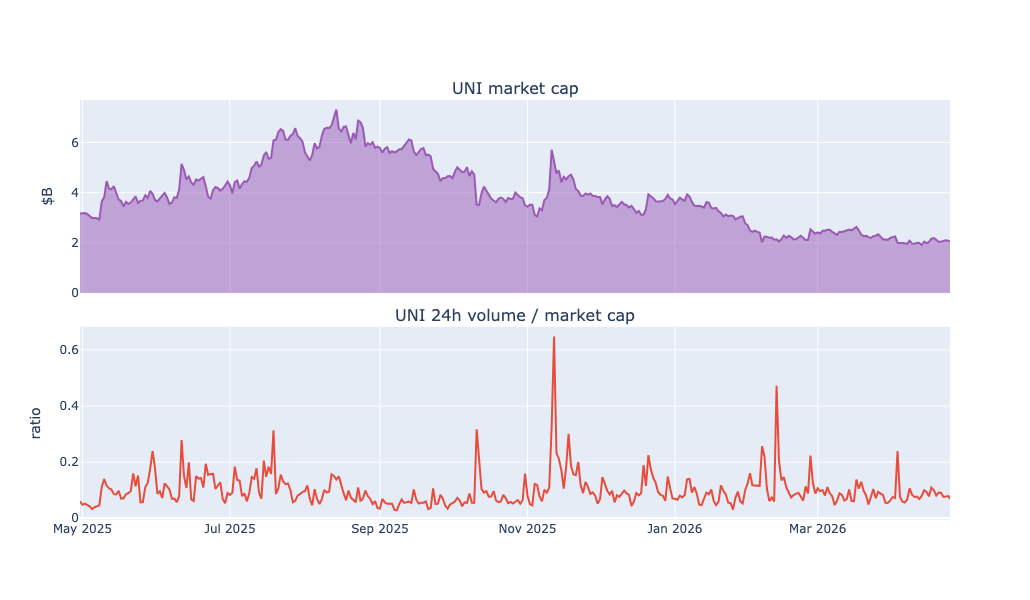

In [44]:
# Market cap vs 24h volume — volume/mcap ratio as a turnover proxy
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
                    subplot_titles=('UNI market cap', 'UNI 24h volume / market cap'))
fig.add_trace(go.Scatter(x=uni_cg['datetime'], y=uni_cg['mcap']/1e9,
                         fill='tozeroy', line=dict(color='#9b59b6'), name='Market cap'), 1, 1)
fig.add_trace(go.Scatter(x=uni_cg['datetime'], y=uni_cg['volume']/uni_cg['mcap'],
                         line=dict(color='#e74c3c'), name='Turnover'), 2, 1)
fig.update_yaxes(title_text='$B', row=1, col=1)
fig.update_yaxes(title_text='ratio', row=2, col=1)
fig.update_layout(height=600, showlegend=False)
fig.show()

## 8. Cross-source sanity check — one price, three sources

The same asset (WETH in USD terms) is observable from:
- **DEX pool onchain** (Uniswap V3 slot0, via web3py)
- **Indexer** (The Graph — hourly close)
- **CEX** (Binance ETHUSDT klines)

Prices should agree closely; any persistent gap is an arbitrage signal or a data quality issue.

In [47]:
# ETH/USD from The Graph hourly data (close) — already in hr DataFrame
graph_eth = hr[['datetime', 'close']].rename(columns={'close': 'graph'}).copy()

# ETH/USD from Binance (hourly for alignment)
kl_eth = requests.get('https://api.binance.com/api/v3/klines',
                      params={'symbol': 'ETHUSDT', 'interval': '1h', 'limit': 500}, timeout=20).json()
eth_bn = pd.DataFrame(kl_eth, columns=['open_time','open','high','low','close','volume',
                                       'close_time','qav','trades','tbbav','tbqav','ignore'])
eth_bn['datetime'] = pd.to_datetime(eth_bn['open_time'], unit='ms')
eth_bn['binance'] = eth_bn['close'].astype(float)
eth_bn = eth_bn[['datetime', 'binance']]

# Normalize datetime precision — Graph uses seconds, Binance uses ms; merge_asof needs matching dtypes
graph_eth['datetime'] = graph_eth['datetime'].astype('datetime64[ns]')
eth_bn['datetime']    = eth_bn['datetime'].astype('datetime64[ns]')

# Align on datetime
merged = pd.merge_asof(graph_eth.sort_values('datetime'), eth_bn.sort_values('datetime'),
                       on='datetime', tolerance=pd.Timedelta('1h'), direction='nearest')
merged = merged.dropna().reset_index(drop=True)
merged['spread_bps'] = (merged['graph'] - merged['binance']) / merged['binance'] * 10000
print(f"Onchain snapshot (current slot0):  ${eth_price_usd:,.2f}")
print(f"Mean spread Graph vs Binance:       {merged['spread_bps'].mean():+.2f} bps")
print(f"Std of spread:                      {merged['spread_bps'].std():.2f} bps")

Onchain snapshot (current slot0):  $2,317.39
Mean spread Graph vs Binance:       +2.76 bps
Std of spread:                      4.07 bps


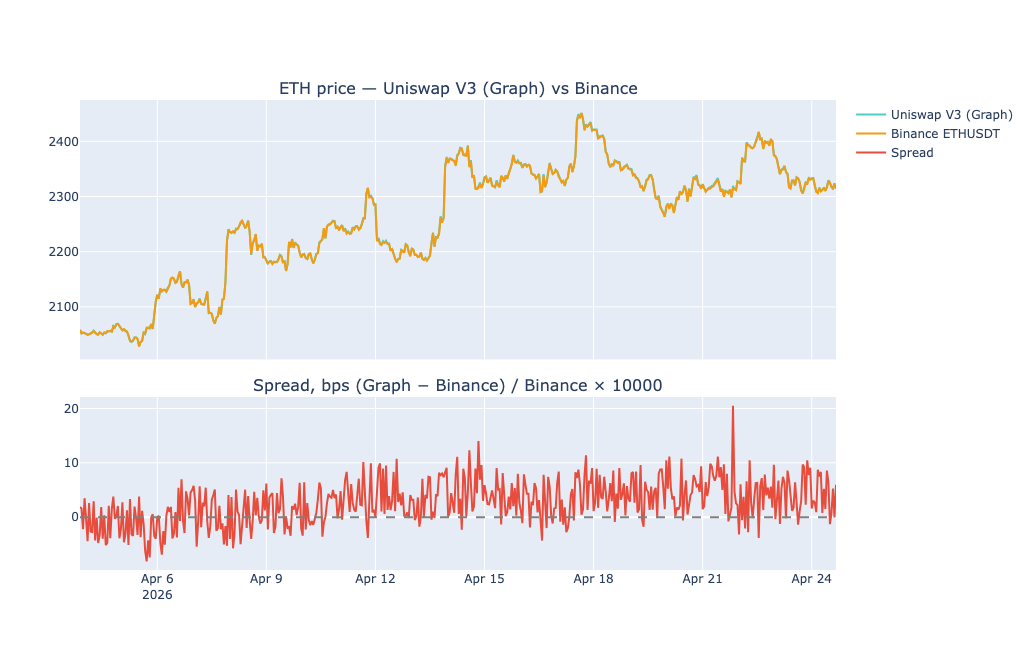

In [48]:
# Two panels: price overlay + spread in bps
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.08,
                    subplot_titles=('ETH price — Uniswap V3 (Graph) vs Binance',
                                    'Spread, bps (Graph − Binance) / Binance × 10000'),
                    row_heights=[0.6, 0.4])
fig.add_trace(go.Scatter(x=merged['datetime'], y=merged['graph'], name='Uniswap V3 (Graph)',
                         line=dict(color='#4ecdc4')), 1, 1)
fig.add_trace(go.Scatter(x=merged['datetime'], y=merged['binance'], name='Binance ETHUSDT',
                         line=dict(color='#f39c12')), 1, 1)
fig.add_trace(go.Scatter(x=merged['datetime'], y=merged['spread_bps'], name='Spread',
                         line=dict(color='#e74c3c')), 2, 1)
fig.add_hline(y=0, line_dash='dash', line_color='grey', row=2, col=1)
fig.update_layout(height=650, hovermode='x unified')
fig.show()

## 9. Key takeaways on Uniswap

**Version dynamics**
- V3 has been the dominant version by TVL since 2021 — concentrated liquidity clearly won on capital efficiency
- V2 still holds sticky liquidity despite V3's launch: not all LPs migrate
- V4 (2025) is in adoption phase — growing but an order of magnitude below V3

**Market position**
- Uniswap consistently captures a meaningful slice of total DeFi TVL; dominance oscillates with the cycle and with rising competition (Curve, Balancer, Aerodrome, PancakeSwap)
- During DeFi bear markets Uniswap's relative share tends to rise — more resilient than average

**Multichain footprint**
- Ethereum mainnet still holds the majority of V3 liquidity
- L2s (Arbitrum, Base, Optimism, Polygon) are material contributors — the multi-chain strategy works
- Long tail of chains contributes only a small fraction — strong concentration effect

**Pool-level observations**
- Stablecoin–ETH pairs dominate 24h volume (USDC/WETH 0.05% is the single largest pool)
- Top pools by volume are not always top by liquidity — concentrated LP positions deliver high capital efficiency (visible as outliers in the volume-vs-liquidity scatter)
- Hourly volume pattern shows distinct US/EU session peaks
- Users are relatively sticky: the avg swaps-per-user-per-day from Dune is substantial, indicating active traders rather than one-off users

**Price integrity**
- Uniswap V3 ETH price agrees with Binance ETHUSDT within a few basis points on average — efficient arbitrage between DEX and CEX
- Persistent spreads would be arbitrage opportunities; we don't see them
- Uniswap is a reliable on-chain price source for ETH/USD, suitable for TWAP oracles

**UNI token**
- UNI has deep CEX liquidity (Binance) and active on-chain transfers
